In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from fastai.text.all import *

In [2]:
# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
set_seed(SEED, reproducible=True)

# Load AG News dataset from CSV files
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Rename columns to standard names
train_df.columns = ["label", "title", "description"]
test_df.columns = ["label", "title", "description"]

# AG News labels
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

train_df["label_name"] = train_df["label"].map(label_map)
test_df["label_name"] = test_df["label"].map(label_map)

# Combine title and description
train_df["text"] = train_df["title"] + " " + train_df["description"]
test_df["text"] = test_df["title"] + " " + test_df["description"]

# Reduce dataset size for faster training
SAMPLE_PER_CLASS = 3000

train_df = (
    train_df
    .groupby("label_name", group_keys=False)
    .apply(lambda x: x.sample(n=SAMPLE_PER_CLASS, random_state=SEED))
    .reset_index(drop=True)
)

print("Reduced training set shape:", train_df.shape)

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

print(train_df.head())

Reduced training set shape: (12000, 5)
Training set shape: (12000, 5)
Test set shape: (7600, 5)
   label                                      title  \
0      3                US house sales fall in July   
1      3                  DJ to acquire MarketWatch   
2      3         Dollar hits new low on Snow speech   
3      3             Yukos executives 'flee' Russia   
4      3  Smithfield quarterly profits beat outlook   

                                                                                                                                                                                                                                      description  \
0                                                                                                                                                         Sales of non-new houses in the US fell last month but still exceeded analyst forecasts.   
1                                                               Dow Jones  amp; Co.

/tmp/ipykernel_9053/560963873.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=SAMPLE_PER_CLASS, random_state=SEED))


In [3]:
# Prepare training data

X_train = train_df["text"]
y_train = train_df["label_name"]

X_test = test_df["text"]
y_test = test_df["label_name"]

Model saved as model.joblib

Traditional Model Accuracy: 0.8978947368421053

Classification Report:
              precision    recall  f1-score   support

    Business       0.87      0.86      0.86      1900
    Sci/Tech       0.88      0.87      0.87      1900
      Sports       0.94      0.97      0.95      1900
       World       0.91      0.90      0.90      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



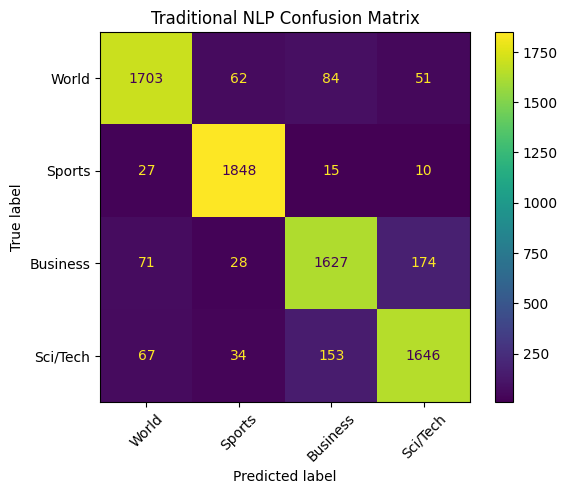

In [5]:
from sklearn.pipeline import Pipeline
import joblib

# TF-IDF vectorizer
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),
    max_features=50000,
    min_df=2
)

# Logistic Regression classifier
clf = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

# Create a pipeline that combines TF-IDF and classifier
# This is required for deployment (ensures consistent preprocessing)
model = Pipeline([
    ("tfidf", tfidf),
    ("clf", clf)
])

# Train the full pipeline on raw text
model.fit(X_train, y_train)

# Save the trained model (pipeline)
joblib.dump(model, "model.joblib")
print("Model saved as model.joblib")

# Convert text to TF-IDF features
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression classifier
clf = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

# Train model
clf.fit(X_train_tfidf, y_train)

# Predict
traditional_preds = clf.predict(X_test_tfidf)

# Accuracy
traditional_accuracy = accuracy_score(y_test, traditional_preds)

print("\nTraditional Model Accuracy:", traditional_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, traditional_preds))

# Confusion matrix
cm = confusion_matrix(
    y_test,
    traditional_preds,
    labels=list(label_map.values())
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(label_map.values())
)

disp.plot(xticks_rotation=45)
plt.title("Traditional NLP Confusion Matrix")
plt.show()

In [ ]:
# Reduce dataset size for faster training
SAMPLE_PER_CLASS = 2000

train_df = (
    train_df
    .groupby("label_name", group_keys=False)
    .apply(lambda x: x.sample(n=SAMPLE_PER_CLASS, random_state=SEED))
    .reset_index(drop=True)
)

print("Reduced training set:", train_df.shape)

# ULMFiT Model (fastai)
print("Training ULMFiT Model")

# Create validation split
ulmfit_df = train_df.copy()

valid_idx = np.random.rand(len(ulmfit_df)) < 0.1
ulmfit_df["is_valid"] = valid_idx

print("Validation split:")
print(ulmfit_df["is_valid"].value_counts())

# Language model DataLoader
dls_lm = TextDataLoaders.from_df(
    ulmfit_df,
    text_col="text",
    is_lm=True,
    valid_col="is_valid",
    bs=64,
    seq_len=72
)

# Train language model
learn_lm = language_model_learner(
    dls_lm,
    AWD_LSTM,
    drop_mult=0.3,
    metrics=[accuracy, Perplexity()]
)

learn_lm.fit_one_cycle(1, 2e-2)

learn_lm.save_encoder("ag_news_encoder")

# Classifier DataLoader
dls_clas = TextDataLoaders.from_df(
    ulmfit_df,
    text_col="text",
    label_col="label_name",
    valid_col="is_valid",
    bs=64,
    seq_len=72
)

# Train classifier
learn_clas = text_classifier_learner(
    dls_clas,
    AWD_LSTM,
    drop_mult=0.5,
    metrics=accuracy
)

learn_clas.load_encoder("ag_news_encoder")

learn_clas.fit_one_cycle(1, 2e-2)

learn_clas.freeze_to(-2)
learn_clas.fit_one_cycle(1, slice(1e-3,1e-2))

learn_clas.freeze_to(-3)
learn_clas.fit_one_cycle(1, slice(5e-4,5e-3))

learn_clas.unfreeze()
learn_clas.fit_one_cycle(2, slice(1e-4,1e-3))

# Evaluate ULMFiT
print("\nEvaluating ULMFiT model...")

# Faster batch prediction
dl = dls_clas.test_dl(test_df)

preds, _ = learn_clas.get_preds(dl=dl)

pred_labels = preds.argmax(dim=1)

ulmfit_preds = [dls_clas.vocab[i] for i in pred_labels]

ulmfit_accuracy = accuracy_score(y_test, ulmfit_preds)

print("\nULMFiT Accuracy:", ulmfit_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, ulmfit_preds))

# Confusion matrix
cm = confusion_matrix(
    y_test,
    ulmfit_preds,
    labels=list(label_map.values())
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(label_map.values())
)

disp.plot(xticks_rotation=45)
plt.title("ULMFiT Confusion Matrix")
plt.show()

/tmp/ipykernel_9053/2731734991.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=SAMPLE_PER_CLASS, random_state=SEED))


Reduced training set: (8000, 5)
Training ULMFiT Model
Validation split:
is_valid
False    7161
True      839
Name: count, dtype: int64


<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:01&lt;00:00]</div>

epoch,train_loss,valid_loss,accuracy,perplexity,time


In [ ]:
# Model comparison
comparison_df = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression", "ULMFiT (AWD_LSTM)"],
    "Accuracy": [traditional_accuracy, ulmfit_accuracy]
})

print("\nModel Comparison:")
print(comparison_df)

plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()


# Save results
comparison_df.to_csv("model_comparison_results.csv", index=False)


print("\nFinal Summary")

print("Traditional NLP Accuracy:", traditional_accuracy)
print("ULMFiT Accuracy:", ulmfit_accuracy)

if ulmfit_accuracy > traditional_accuracy:
    print("ULMFiT performs better.")
else:
    print("Traditional NLP performs better.")